# 睡眠の質予測
## データの基本情報の確認

In [1]:
import pandas as pd

df = pd.read_csv("data/raw/Sleep_health_and_lifestyle_dataset.csv")
df.head(20)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [2]:
df.shape

(374, 13)

In [3]:
df.info()  # 欠損値とデータタイプの確認

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


In [4]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [5]:
df.groupby("Gender")["Quality of Sleep"].mean()

Gender
Female    7.664865
Male      6.968254
Name: Quality of Sleep, dtype: float64

In [6]:
# 欠損値の確認
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [7]:
df["Sleep Disorder"].value_counts(dropna=False)

Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [8]:
# 欠損値補完
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

In [9]:
# Person IDは予測に関係ないため、削除する。
df = df.drop(columns=["Person ID"])

In [10]:
# BMI統一（Normal WeightとNormalは意味が一緒のため）
df["BMI Category"] = df["BMI Category"].replace(
    {
        "Normal Weight": "Normal"
    }
)

In [11]:
# 血圧の処理（str型で収縮期血圧と拡張期血圧をなので必要がある）
# 120/80 ←収縮期血圧/拡張期血圧

df[["Systolic", "Diastolic"]] = (
    df["Blood Pressure"]
      .str.split("/", expand=True)
      .astype(int)
)

In [12]:
df.head(20)

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
5,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia,140,90
6,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia,140,90
7,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None,120,80
8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None,120,80
9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None,120,80


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    str    
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    str    
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    str    
 8   Blood Pressure           374 non-null    str    
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           374 non-null    str    
 12  Systolic                 374 non-null    int64  
 13  Diastolic                374 non-null    int64  
dtypes: float64(1), int64(8), str(5)
memor

## 可視化

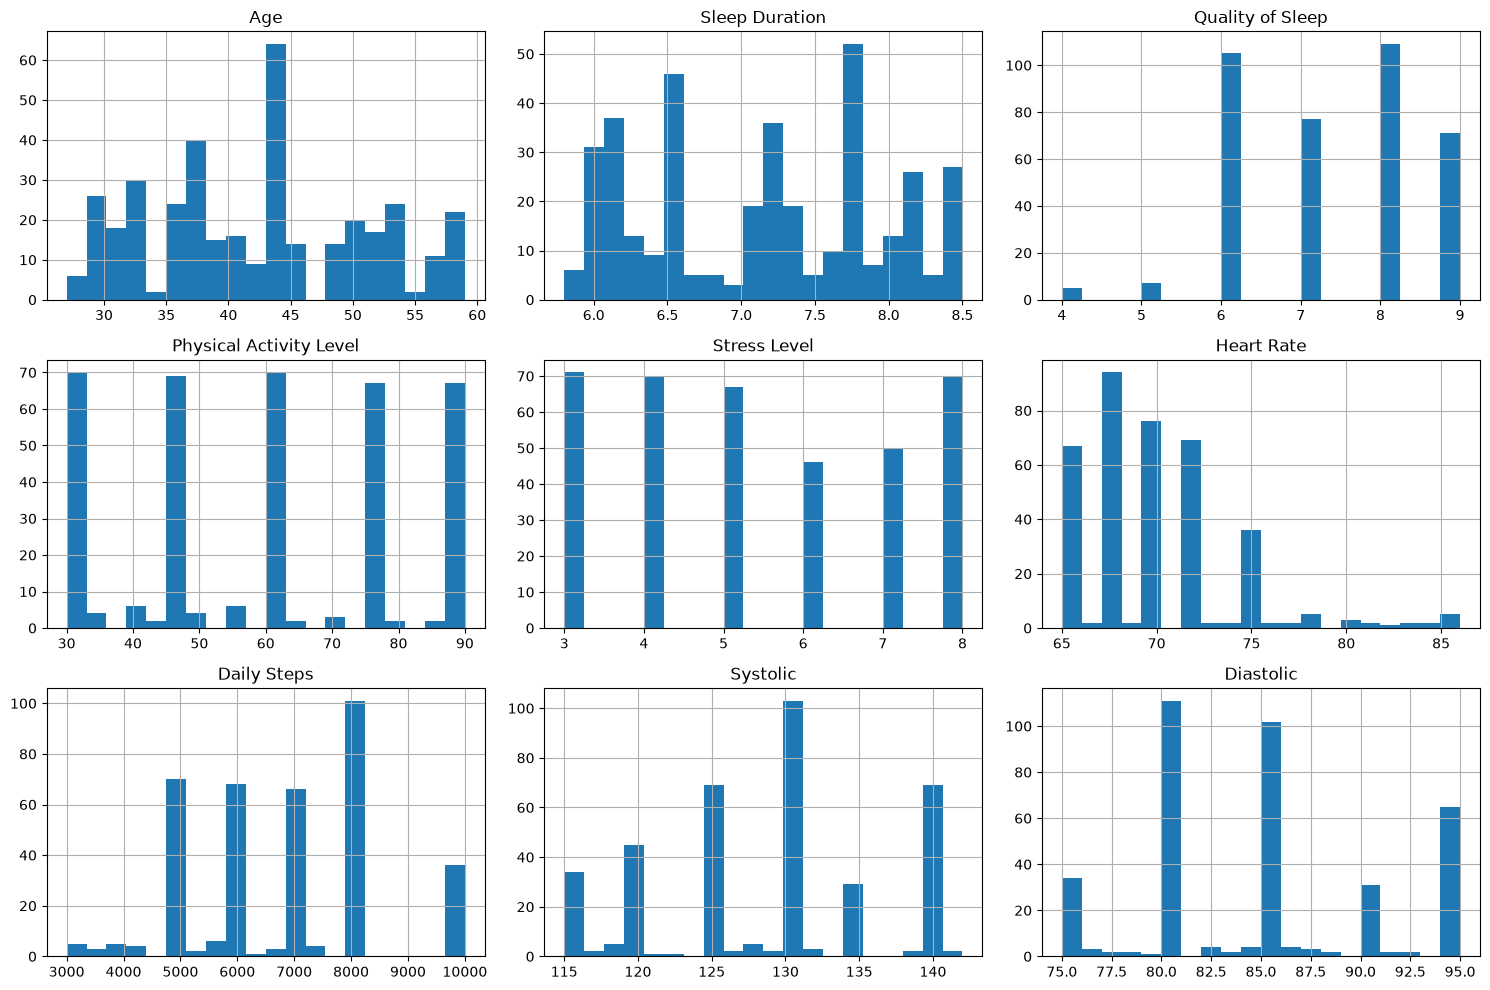

In [14]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

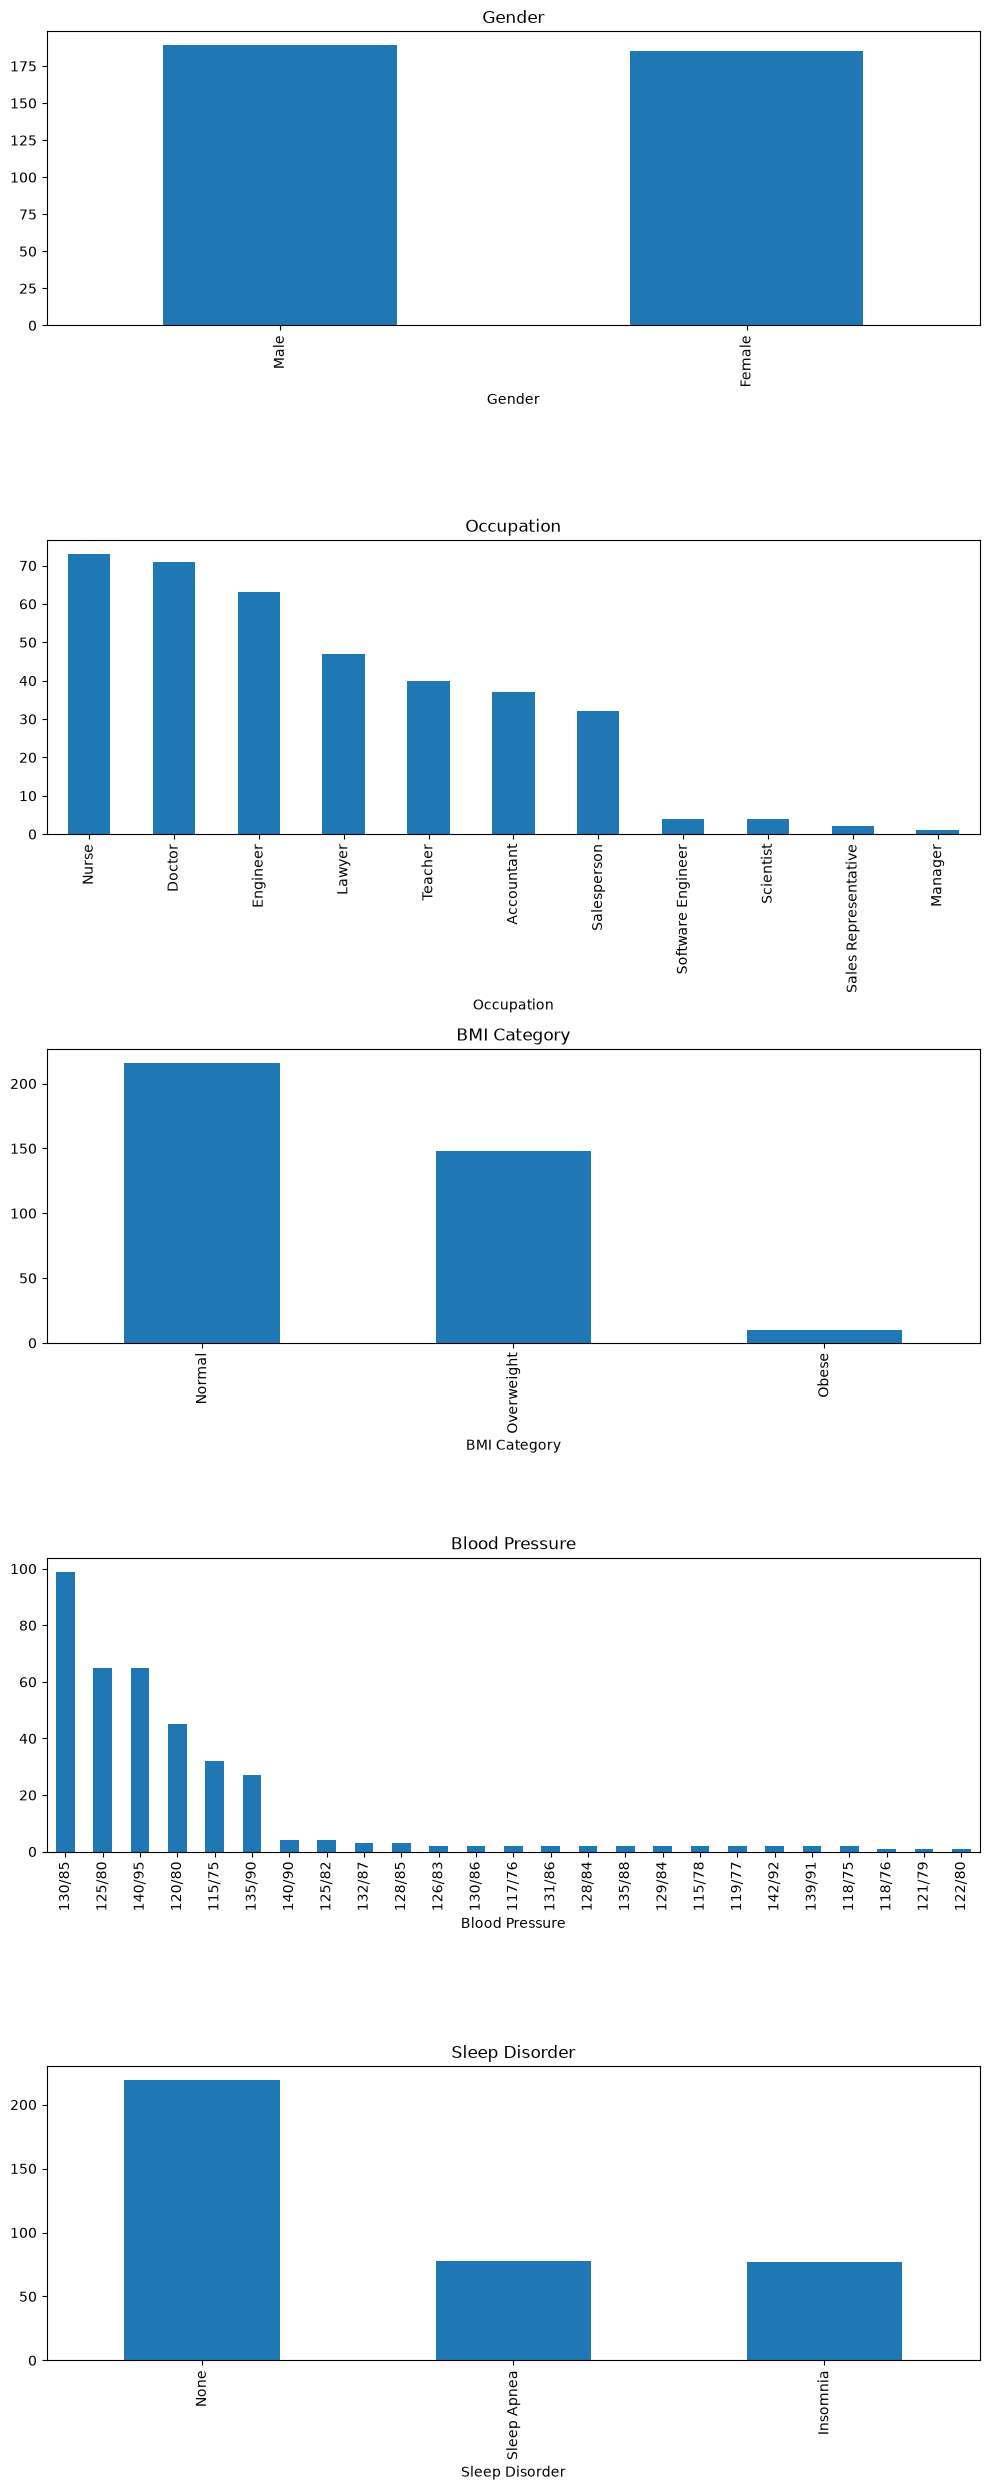

In [15]:
str_cols = df.select_dtypes(exclude="number").columns

fig, axes = plt.subplots(len(str_cols), 1, figsize=(10, 5 * len(str_cols)))

if len(str_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, str_cols):
    df[col].value_counts().plot(
        kind="bar",
        ax=ax,
        title=col
    )

plt.tight_layout()
plt.show()

### 目的変数の確認  
このプロジェクトでは睡眠品質を知りたいので、 **Quality of asleep** との相関を調べる。  
このデータから、以下の特徴量が目的変数との相関関係があることが分かった。  
- Age
- Sleep Duration
- Stress Level
- Heart Rate

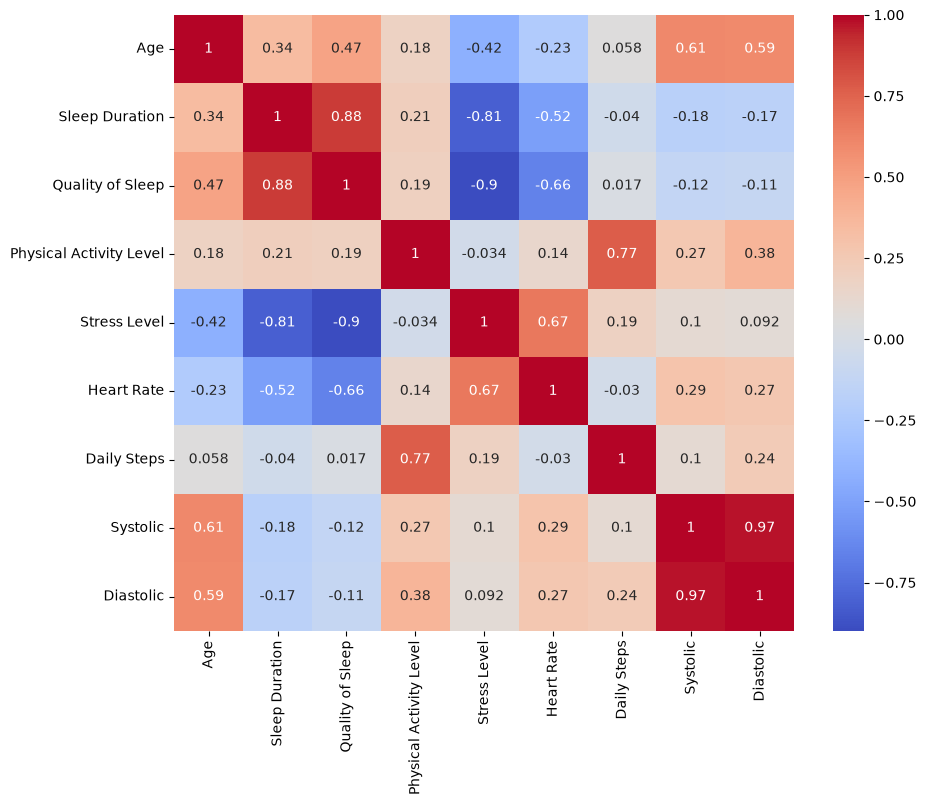

In [16]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.show()

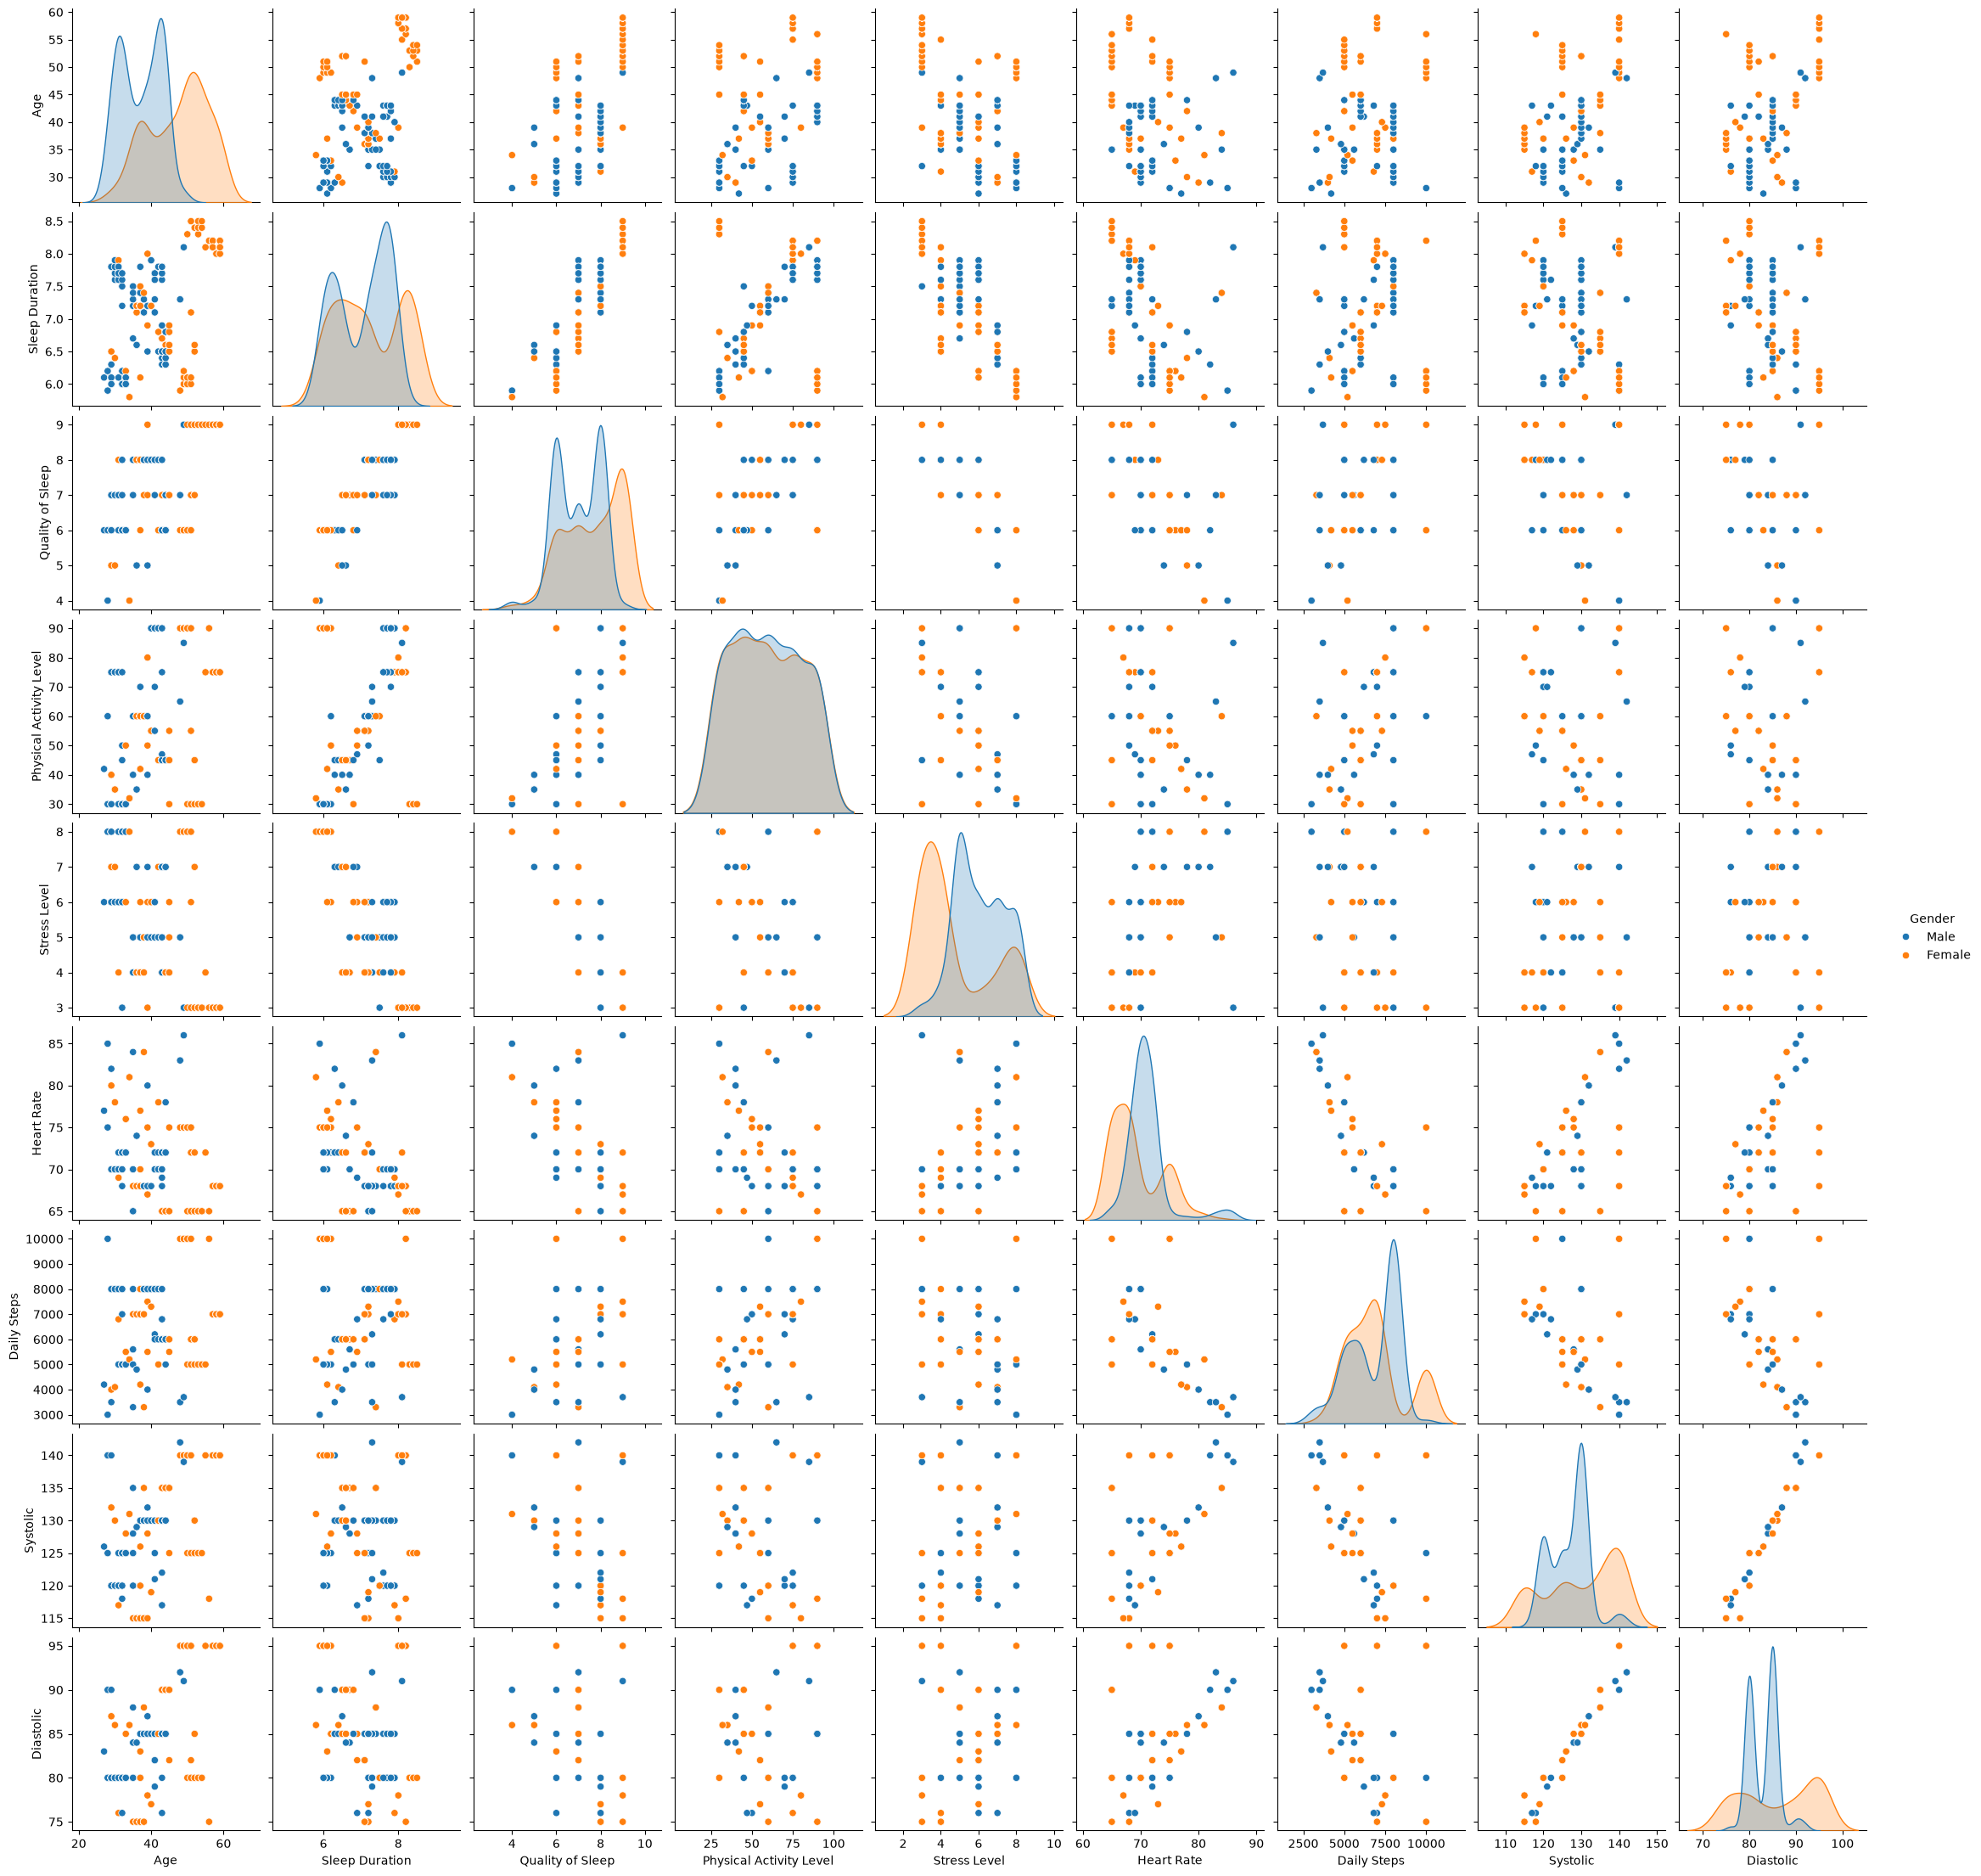

In [17]:
sns.pairplot(df, hue="Gender")
plt.show()

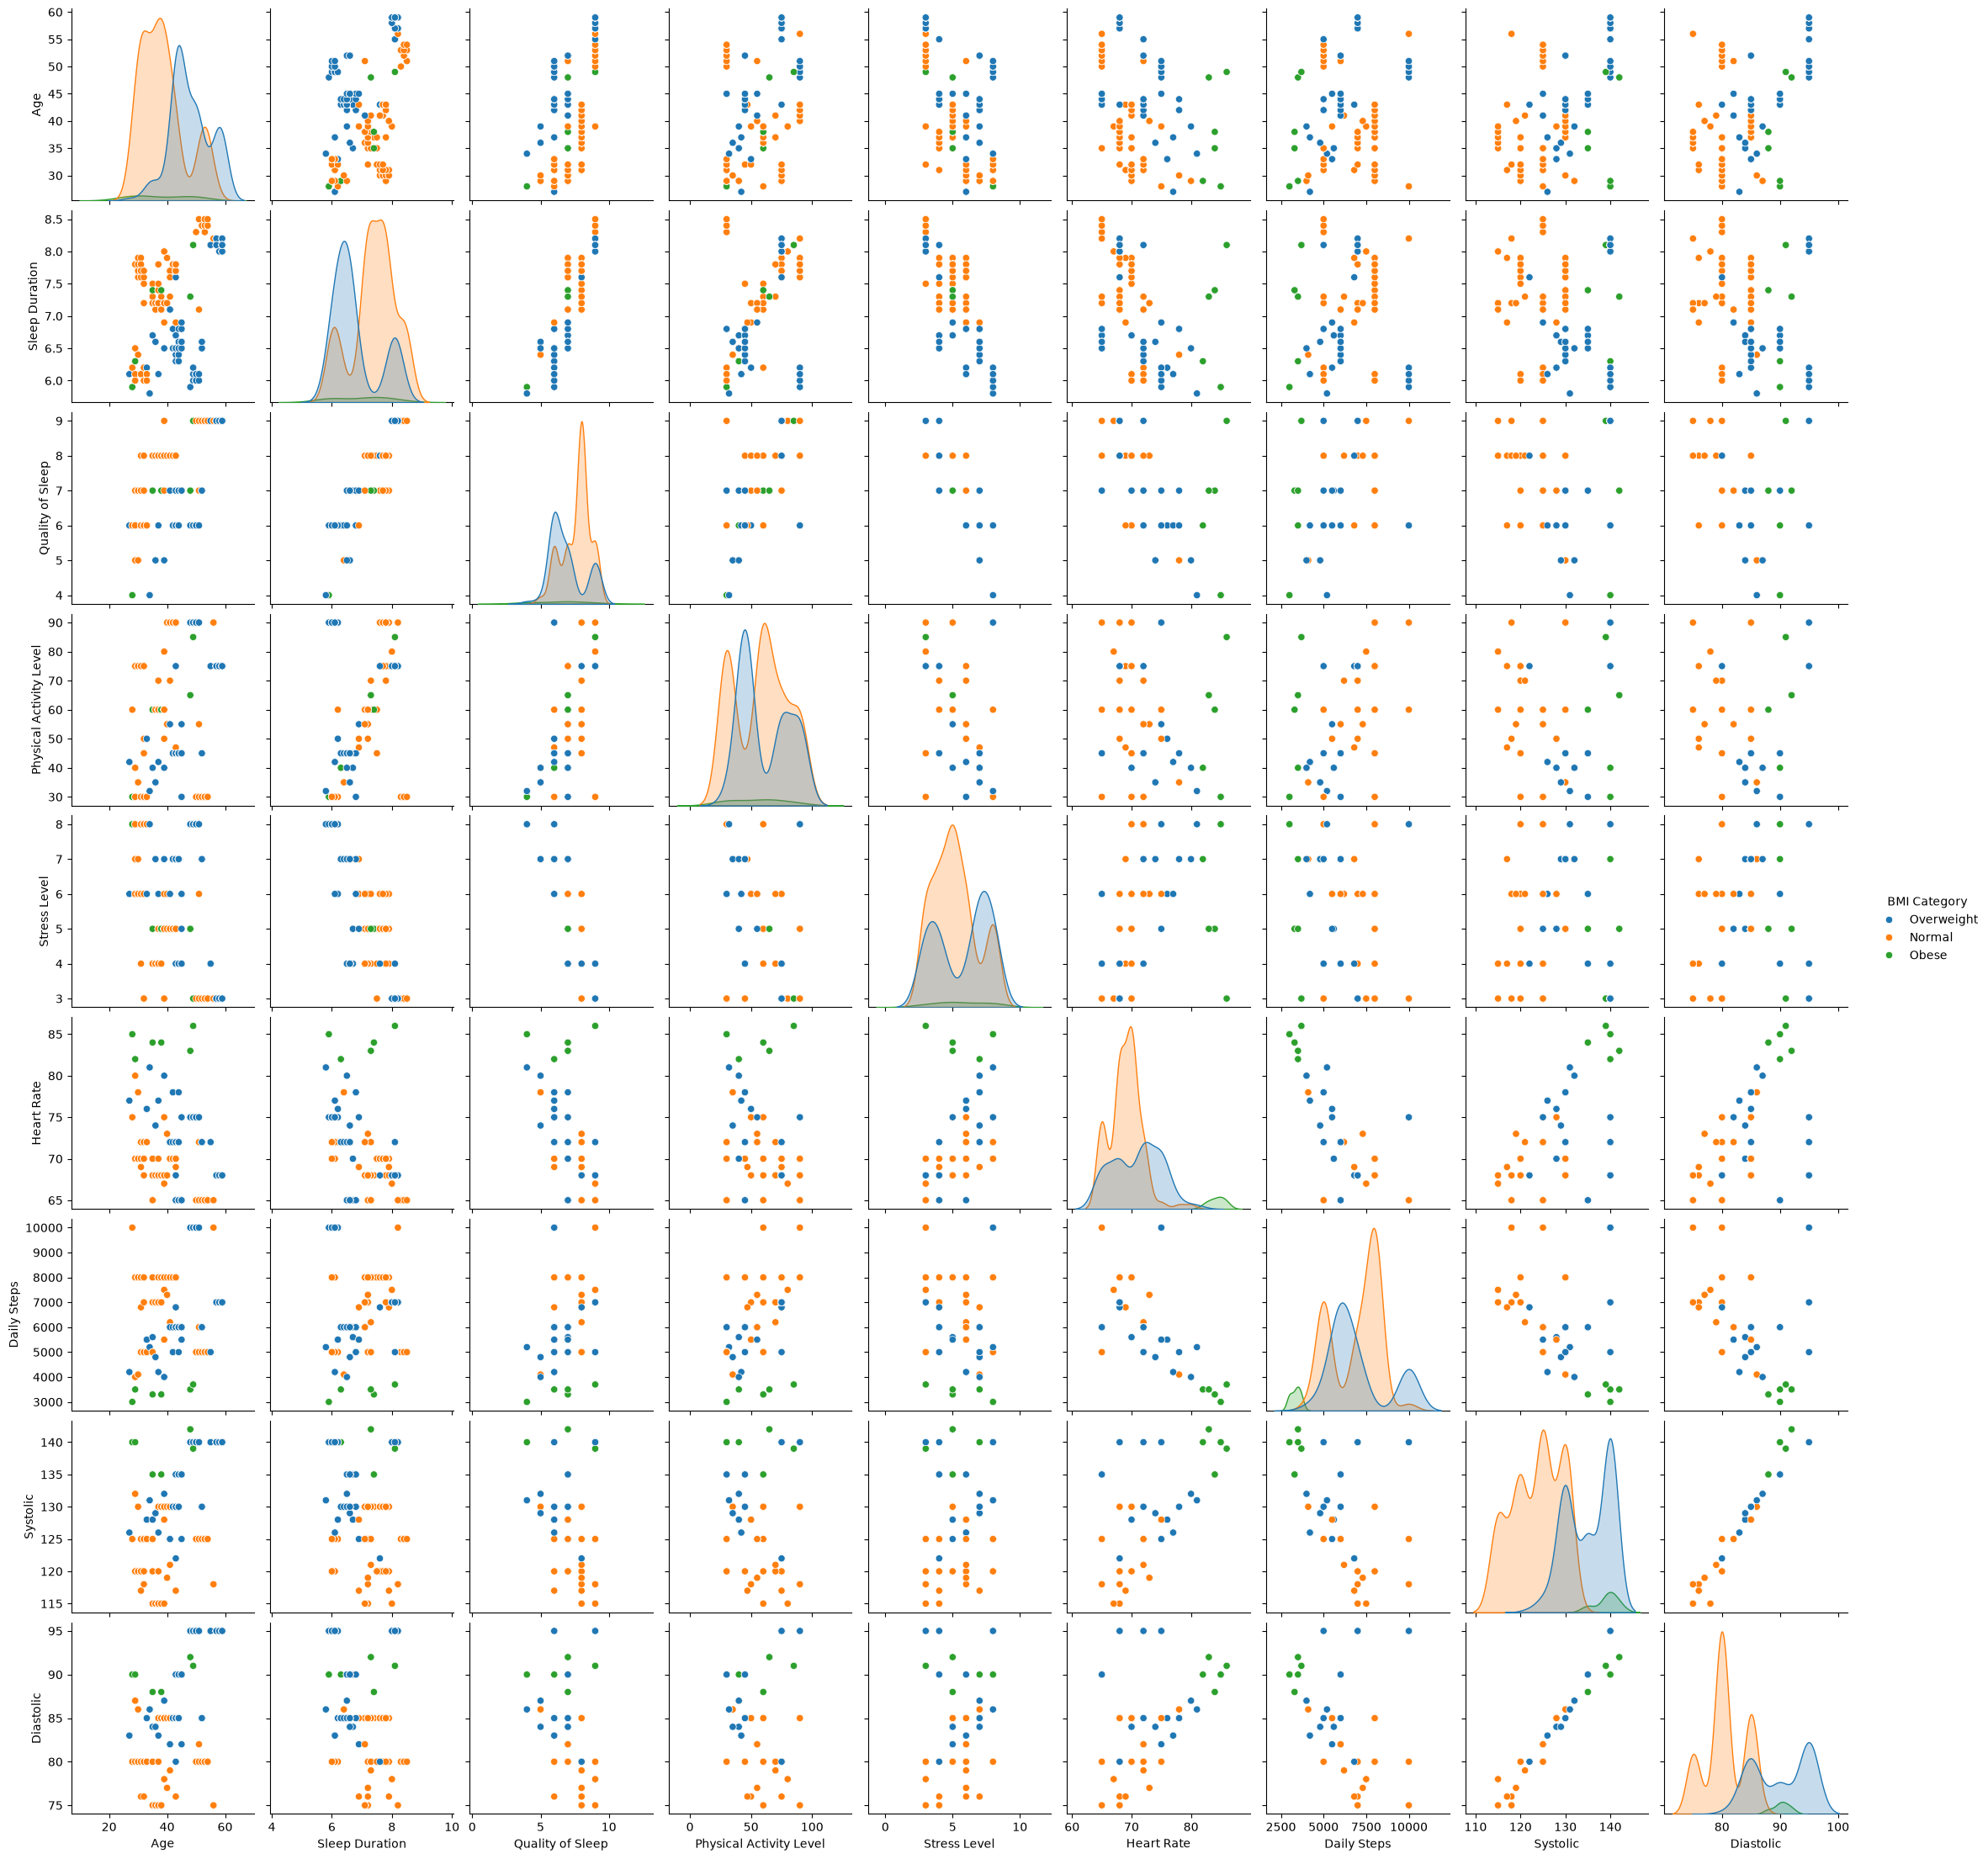

In [18]:
sns.pairplot(df, hue="BMI Category")
plt.show()

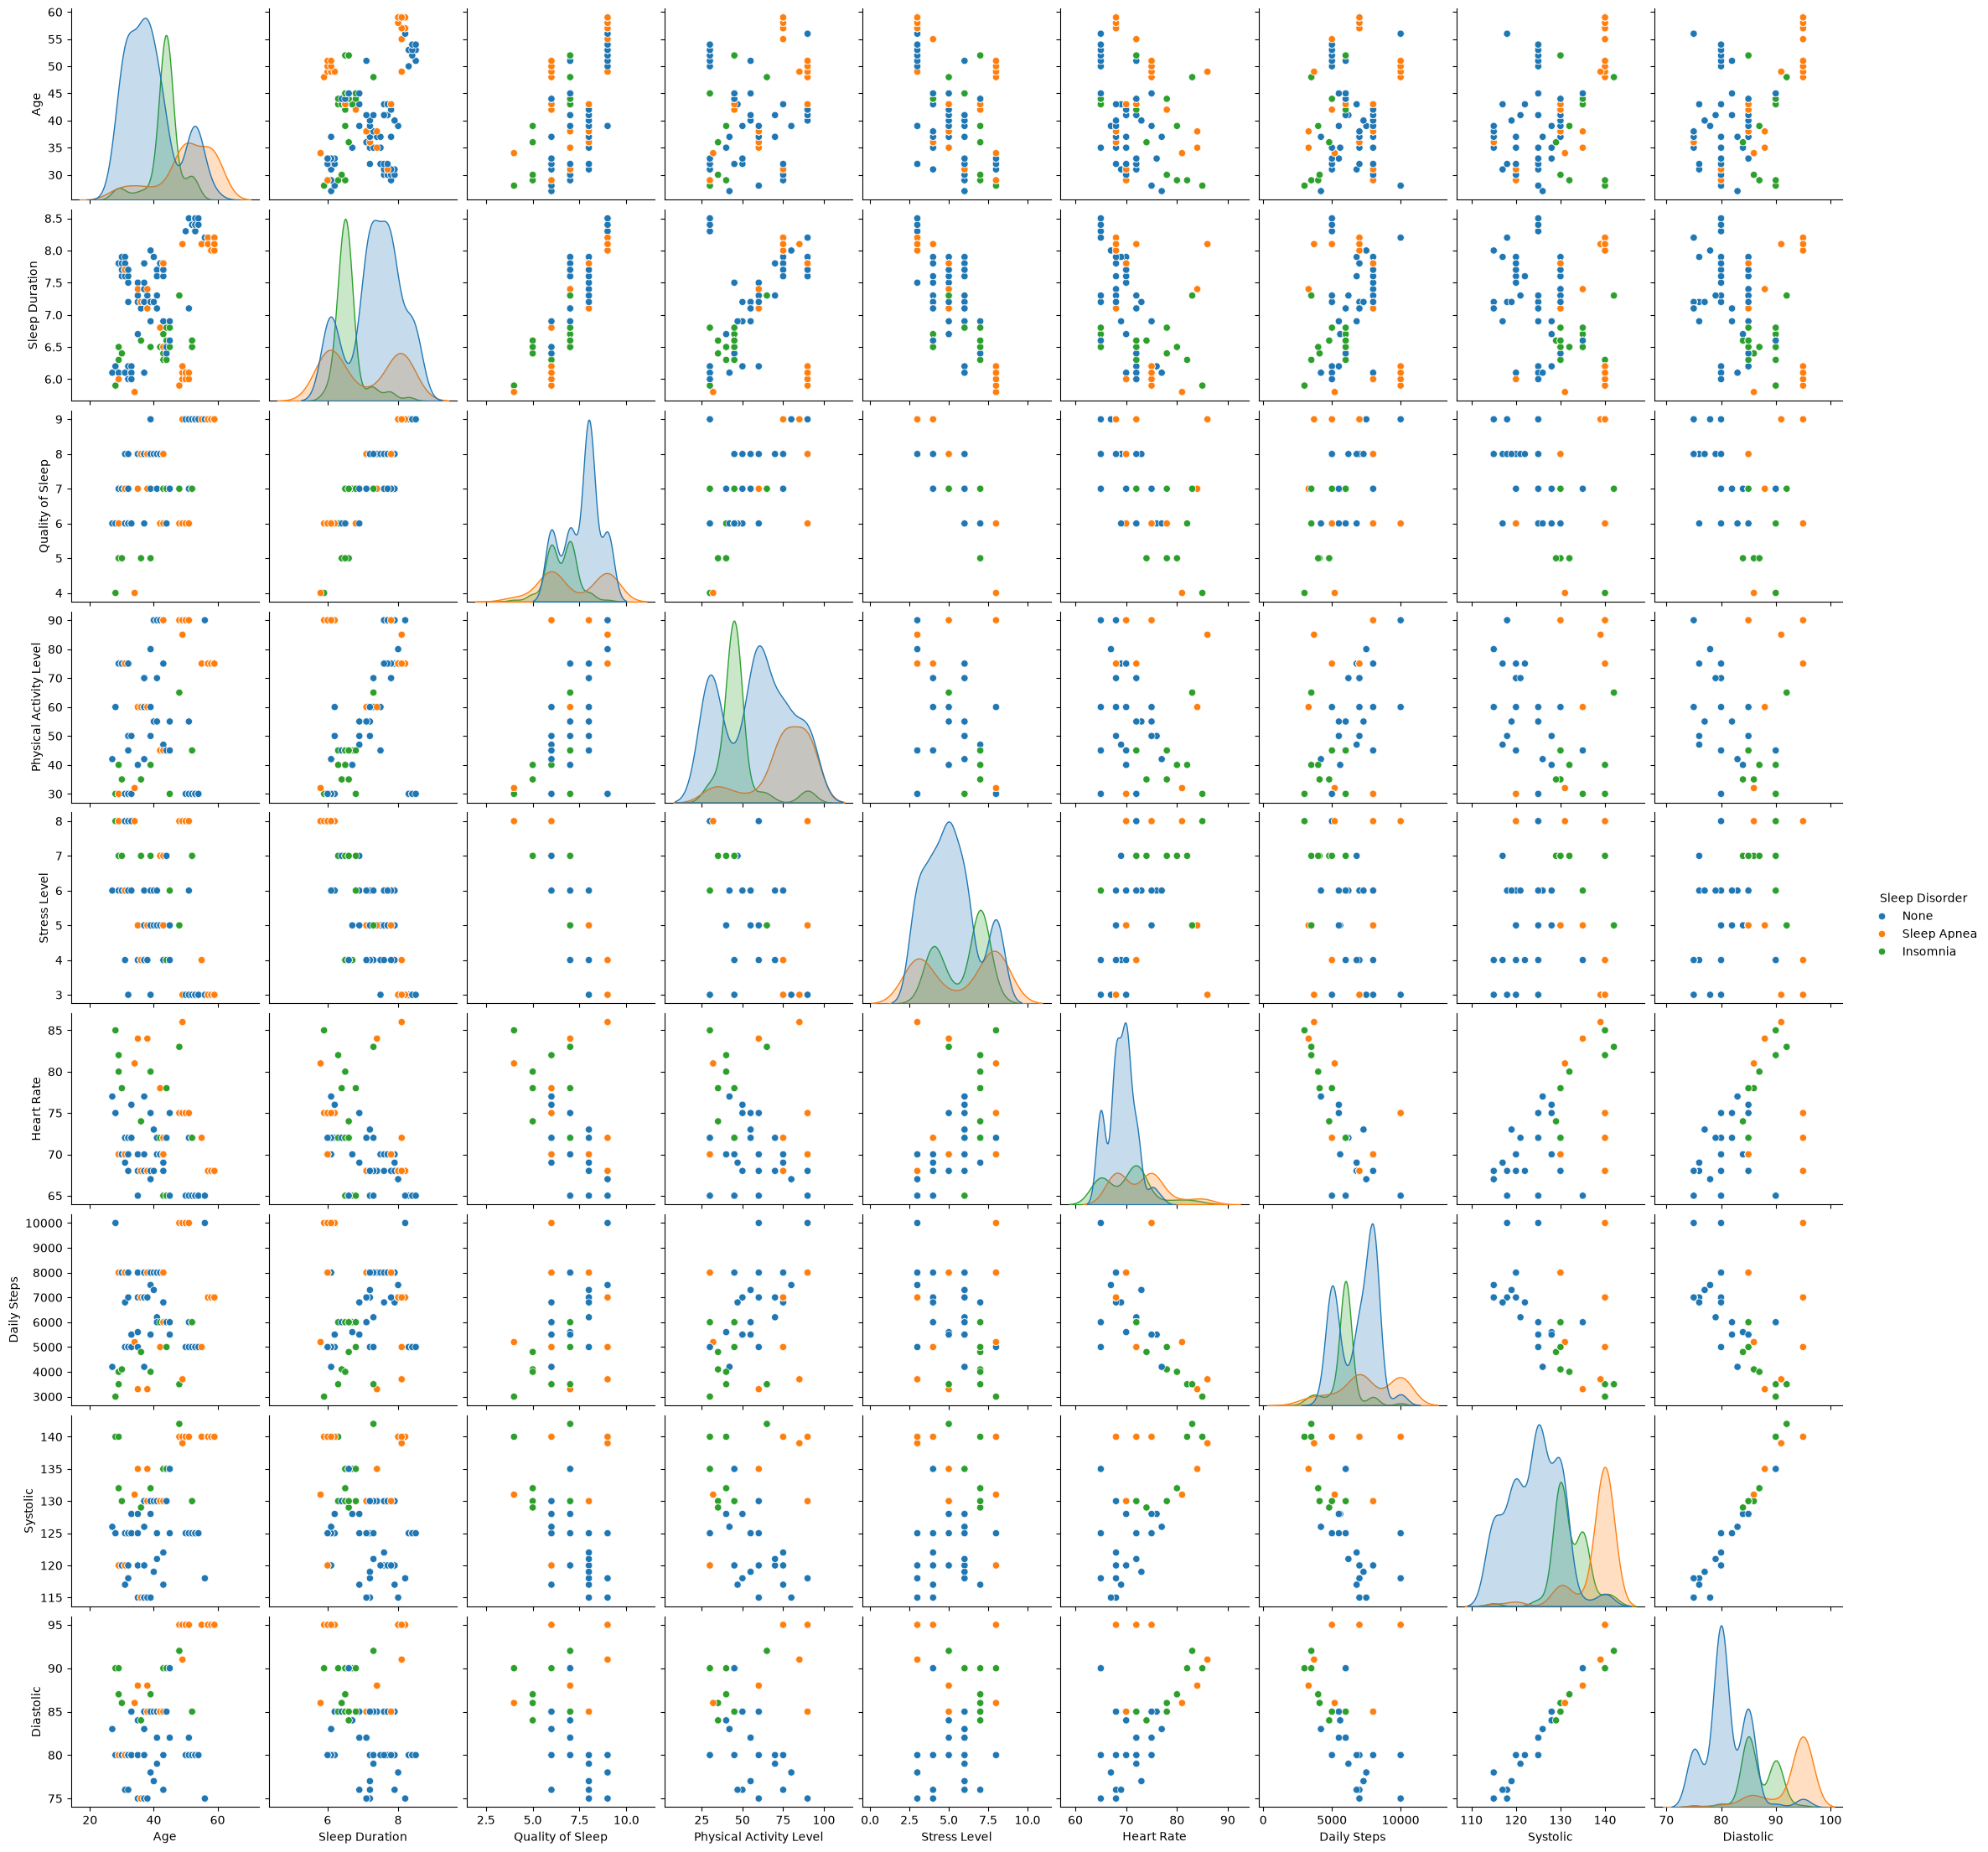

In [19]:
sns.pairplot(df, hue="Sleep Disorder")
plt.show()

## 年齢について
年齢と睡眠の質の結果から、深堀りを行う。

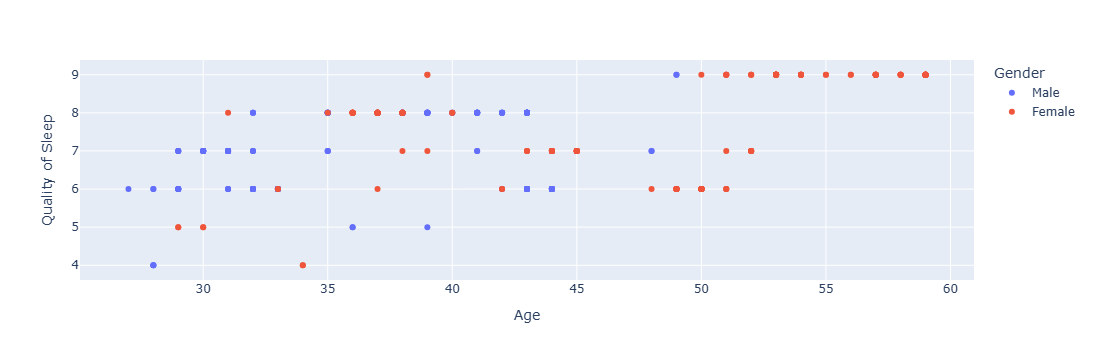

In [20]:
import plotly.express as px

px.scatter(
    df,
    x="Age",
    y="Quality of Sleep",
    color="Gender"
)

# 若い人ほど睡眠の質が悪い（年齢が高いほど睡眠の質が高い）が、調査と矛盾している。
# 50代は女性のみとなっており、睡眠の質が高くなっている（50代について、運動時間や睡眠時間などを調べ、健康的かを調べるといいかも）

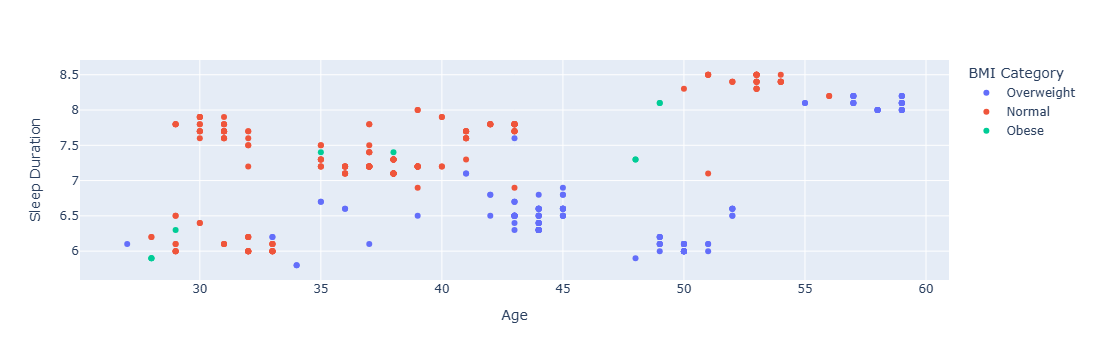

In [21]:
# 年齢と睡眠時間について

px.scatter(
    df,
    x="Age",
    y="Sleep Duration",
    color="BMI Category"
)

# 50代のほとんどは、睡眠時間を十分に確保できている。

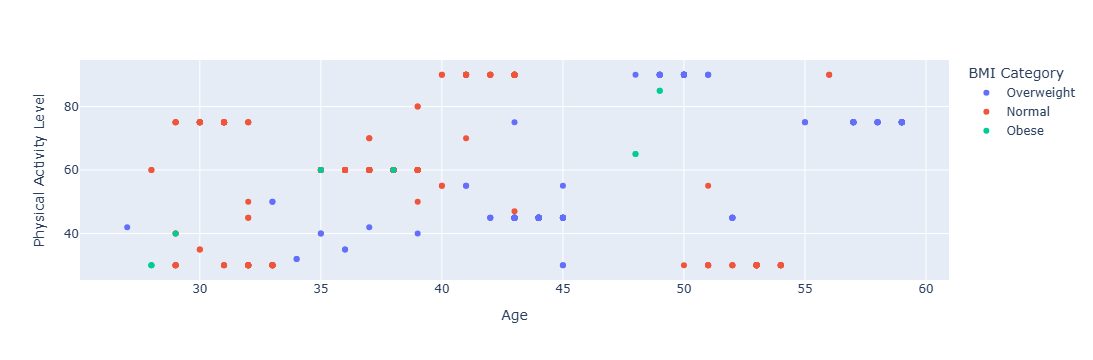

In [22]:
# 年齢と運動時間について

px.scatter(
    df,
    x="Age",
    y="Physical Activity Level",
    color="BMI Category"
)

# 50代のほとんどは、睡眠時間を十分に確保できている。

In [23]:
print(len(df[df["Age"] > 52]))

59


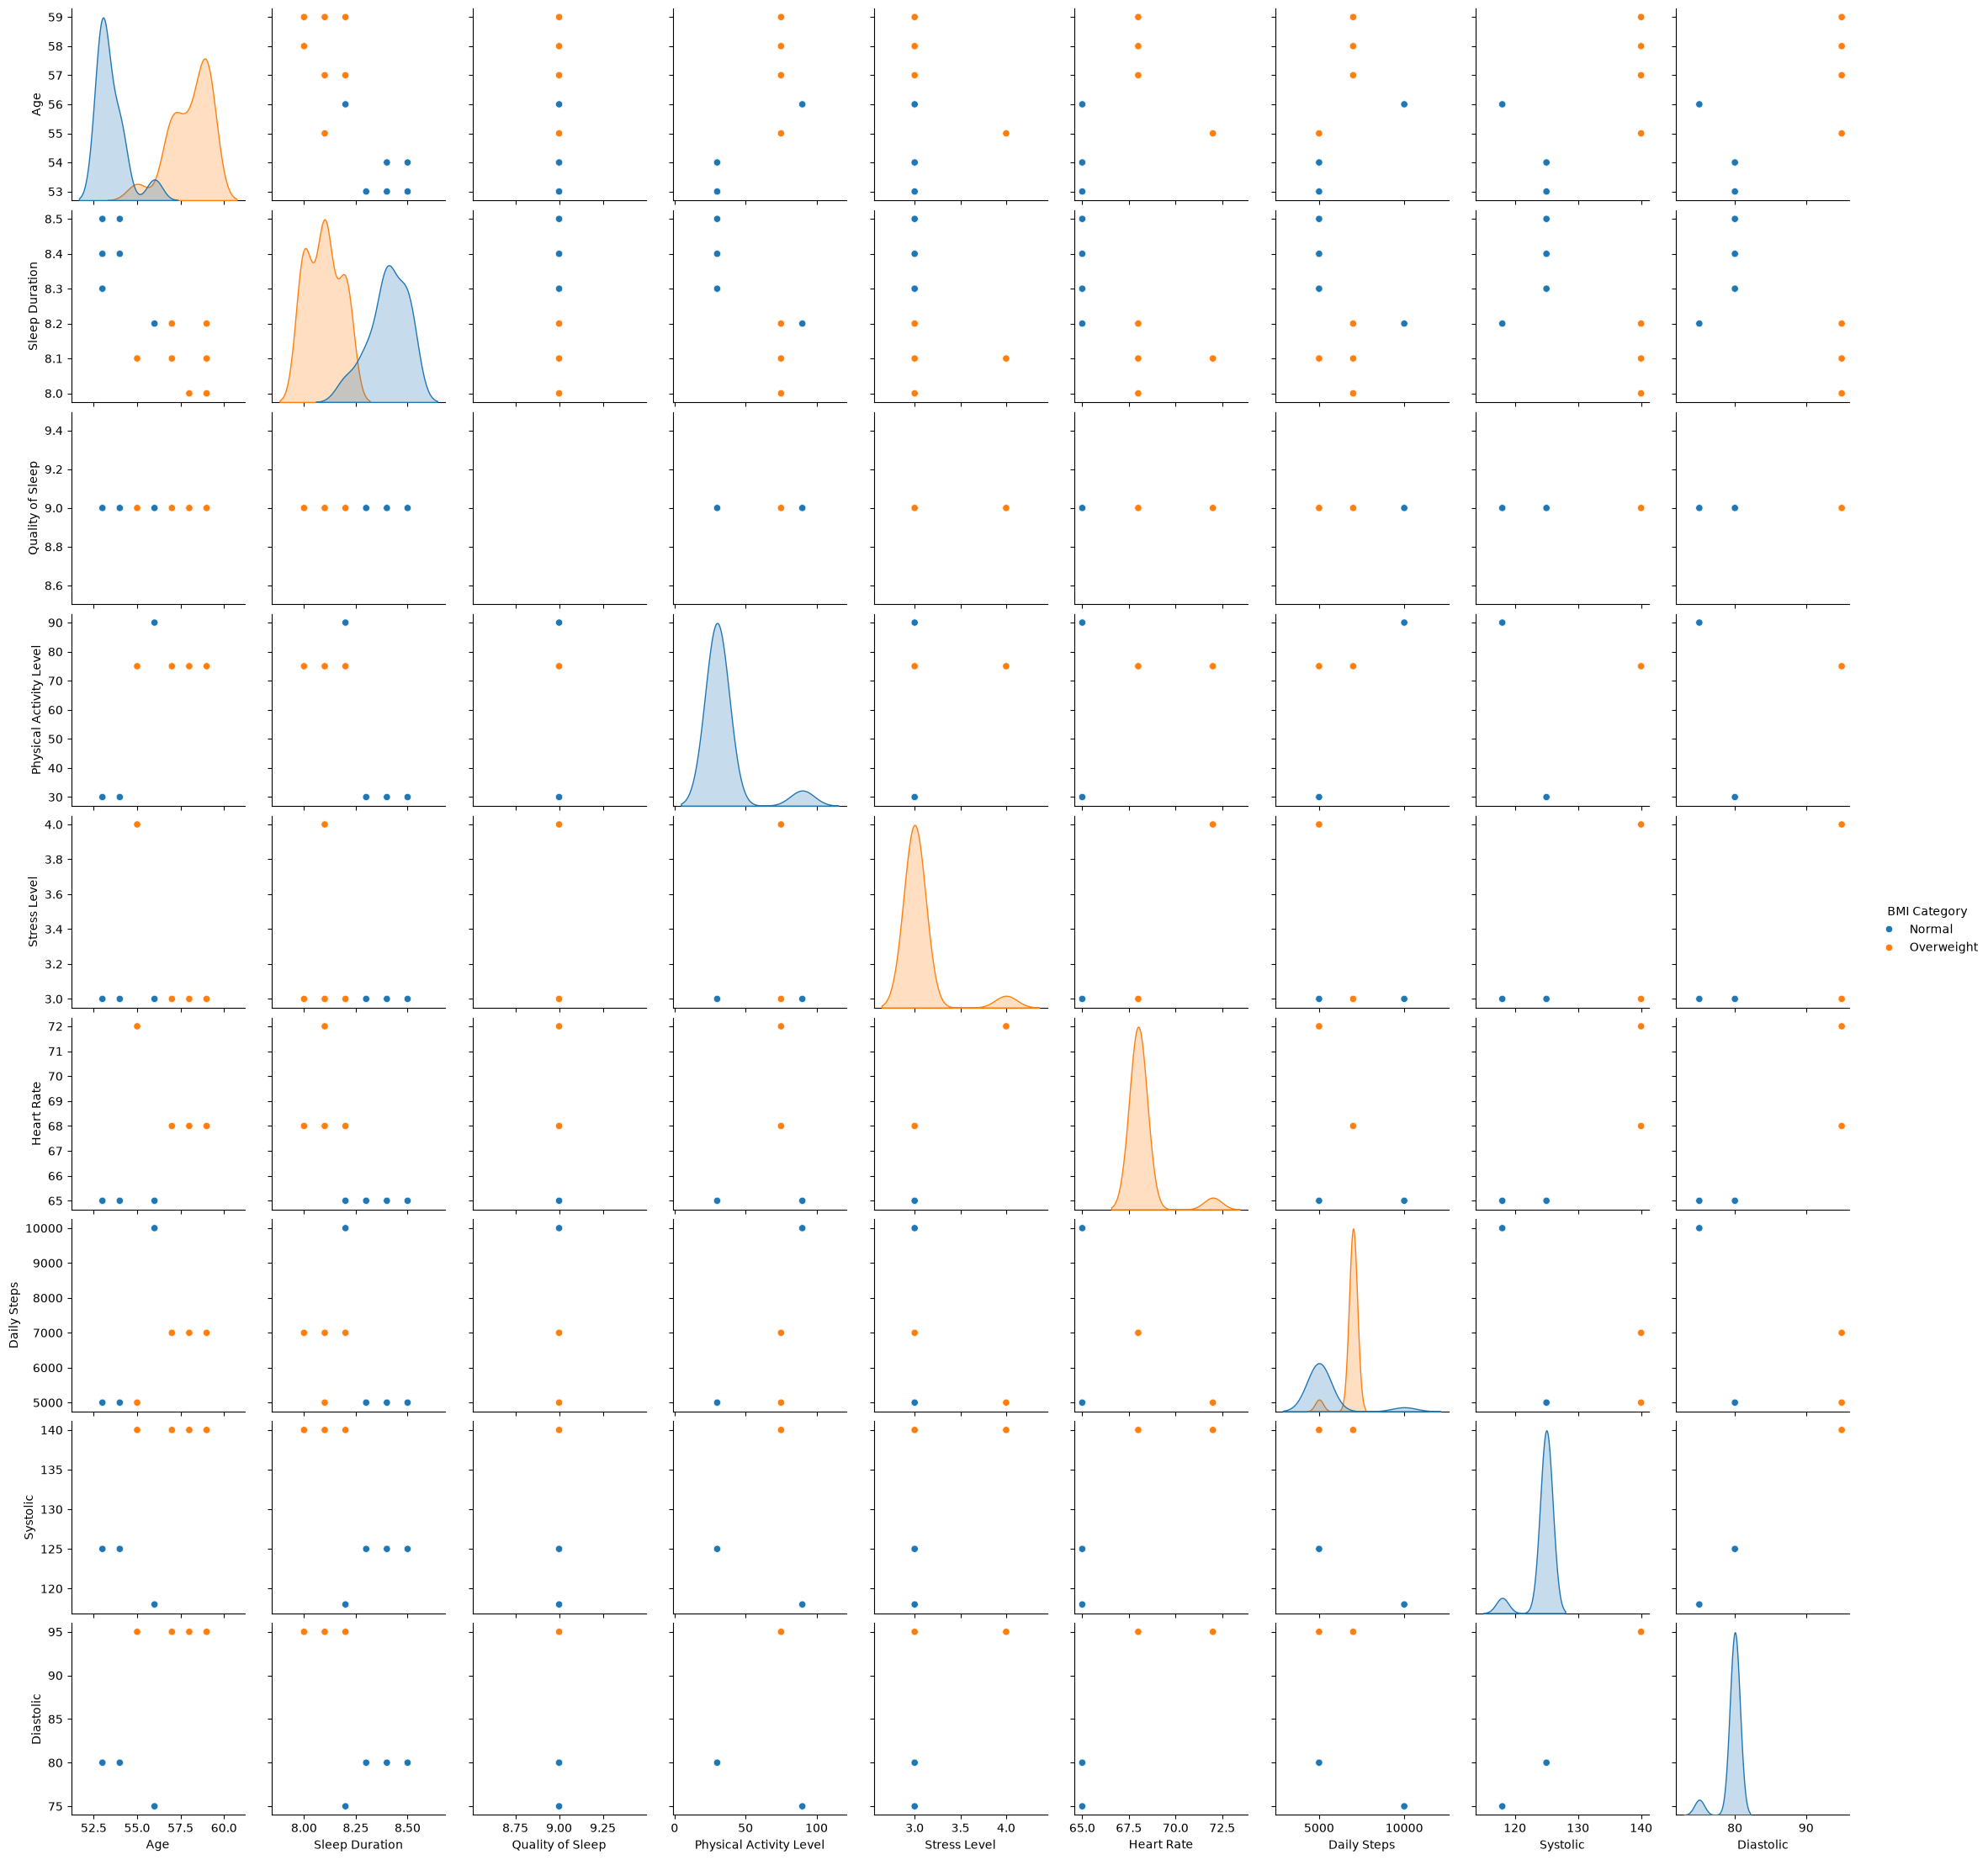

In [24]:
sns.pairplot(df[df["Age"] > 52], hue="BMI Category")
plt.show()

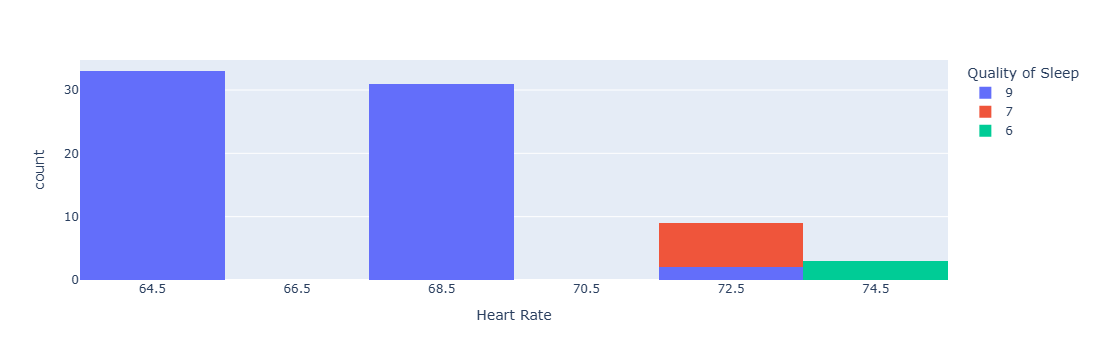

In [25]:
px.histogram(
    df[df["Age"] > 50],
    x="Heart Rate",
    color="Quality of Sleep"
)

# 全員正常な心拍数である

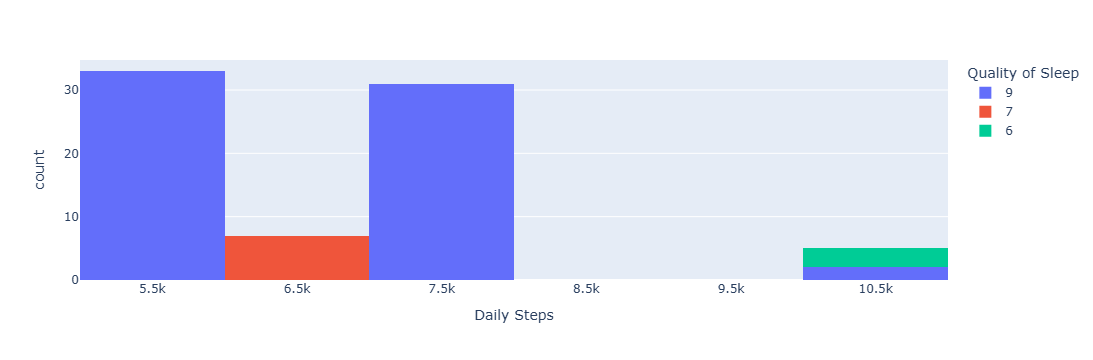

In [26]:
px.histogram(
    df[df["Age"] > 50],
    x="Daily Steps",
    color="Quality of Sleep"
)

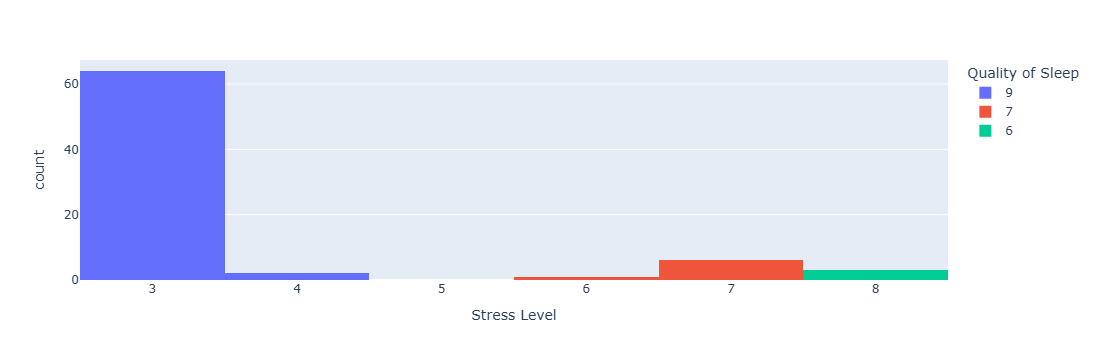

In [27]:
px.histogram(
    df[df["Age"] > 50],
    x="Stress Level",
    color="Quality of Sleep"
)

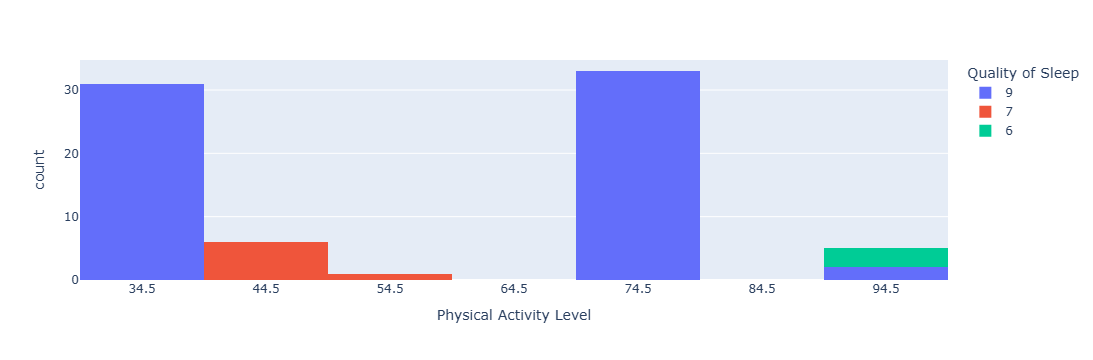

In [28]:
px.histogram(
    df[df["Age"] > 50],
    x="Physical Activity Level",
    color="Quality of Sleep"
)

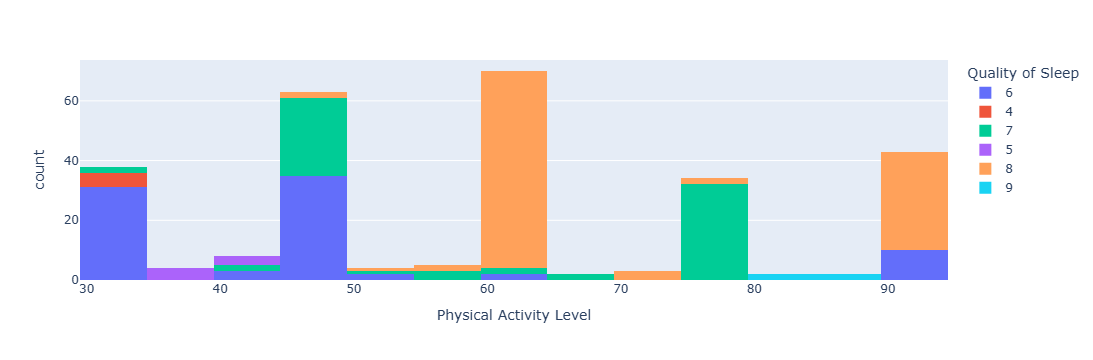

In [29]:
px.histogram(
    df[df["Age"] < 50],
    x="Physical Activity Level",
    color="Quality of Sleep"
)

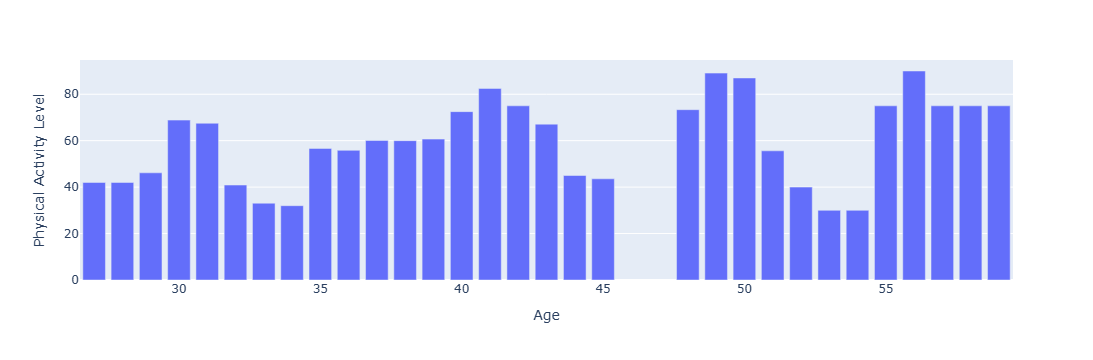

In [30]:
avg_df = (
    df.groupby("Age")["Physical Activity Level"]
    .mean()
    .reset_index()
)

fig = px.bar(
    avg_df,
    x="Age",
    y="Physical Activity Level"
)

fig.show()

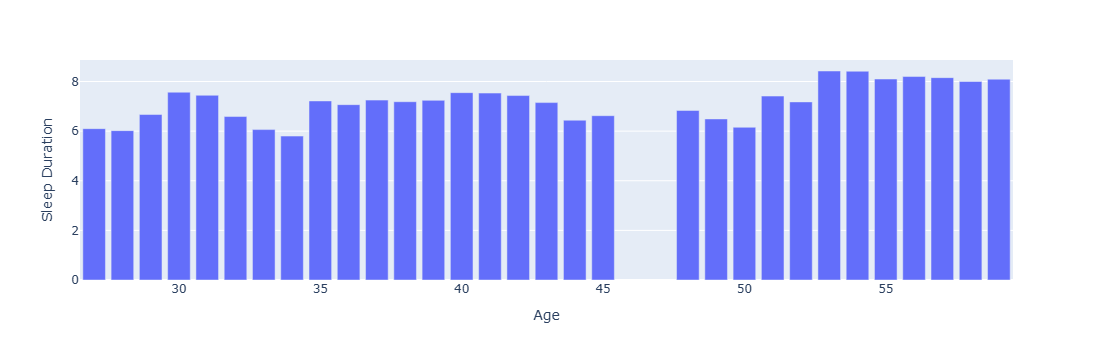

In [31]:
avg_df = (
    df.groupby("Age")["Sleep Duration"]
    .mean()
    .reset_index()
)

fig = px.bar(
    avg_df,
    x="Age",
    y="Sleep Duration"
)

fig.show()

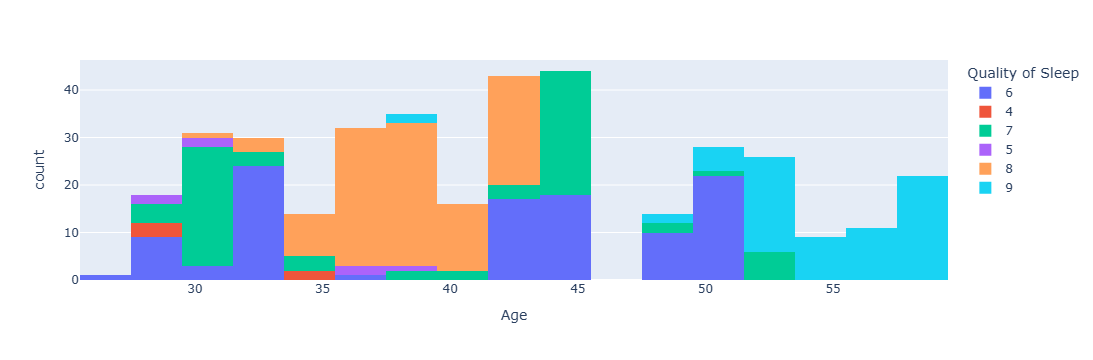

In [32]:
px.histogram(
    df,
    x="Age",
    color="Quality of Sleep"
)

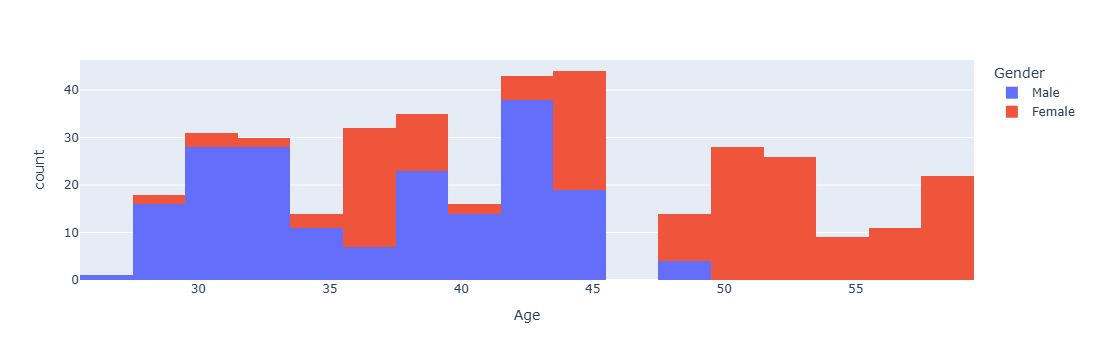

In [33]:
px.histogram(
    df,
    x="Age",
    color="Gender"
)

# 睡眠時間＊年齢　微妙
# 睡眠時間＊質　〇
# 年齢＊質　矛盾（調査によれば年齢が高いほど睡眠が浅くなりがちだが、今回のデータでは年齢が高い方が睡眠の質は上がっている）

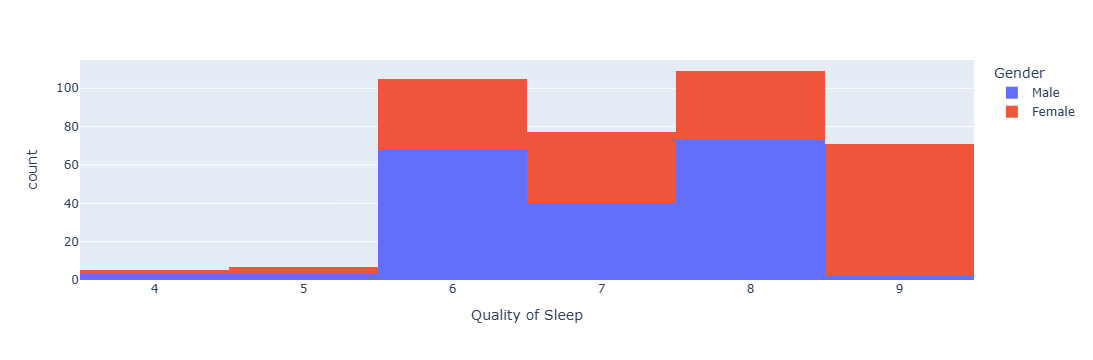

In [34]:
px.histogram(
    df,
    x="Quality of Sleep",
    color="Gender"
)

# 男性は若い人が多い、女性は中年層が多い
# 女性の中年層が一番

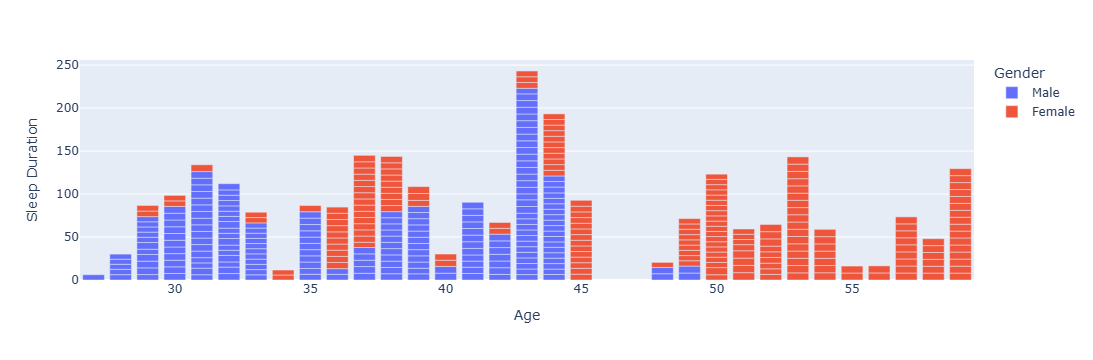

In [35]:
px.bar(
    df,
    x="Age",
    y="Sleep Duration",
    color="Gender"
)

# 男性は若い人が多い、女性は中年層が多い
# 女性の中年層が一番

BMI Categoryを確認したところ、  
Normal、Overweight、Obeseのカテゴリが存在した一方、  
Underweight（やせ型）のサンプルは確認されなかった。  

そのため本モデルは標準体重以上のサンプルを中心に学習しており、  
低体重者に対する予測性能には注意が必要である。

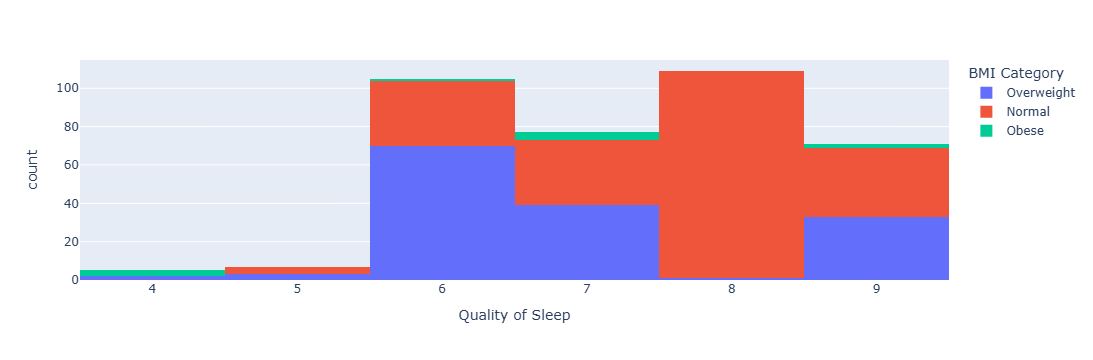

In [36]:
px.histogram(
    df,
    x="Quality of Sleep",
    color="BMI Category"
)

# bmiが標準になればなるほど睡眠の質は高くなる傾向にある。
# それ以外はやや下の方に多い

### 睡眠障害との関係

睡眠障害はない方が睡眠品質が高い。  
障害ある場合でも睡眠品質が良い場合もあるが、  
高品質にも存在しているが、低品質では皆障害ありとなっている。

睡眠障害があるからといって、必ずしも睡眠の質を改善できないわけではない。  
むしろ、多くの睡眠障害では適切な治療や生活習慣の改善によって睡眠の質を向上させることが期待できる。  
例えば、
- 不眠症 → 睡眠衛生の改善、認知行動療法、不眠治療薬などで改善することがある
- 睡眠時無呼吸症候群 → CPAP療法や減量などで睡眠の質が大幅に向上する場合がある

**睡眠の質を上げるポイント**

- 起床時間を毎日できるだけ一定にする
- 朝に日光を浴びる
- 日中に適度な運動をする
- 寝る前のスマホやPCを控える
- カフェインやアルコールを摂りすぎない
- 寝室の温度・湿度・明るさを整える

ただし、睡眠障害そのものが未治療の場合は、生活習慣を改善しても限界があることがあります。 例えば睡眠時無呼吸症候群では、生活改善だけでは十分な効果が得られない場合もあります。  

**このデータでは運動していれば睡眠障害があっても質を高くできる結果となっている。  
睡眠障害限らず、何らかの生活習慣の乱れによって、睡眠の質が左右されることは十分あり得る。**

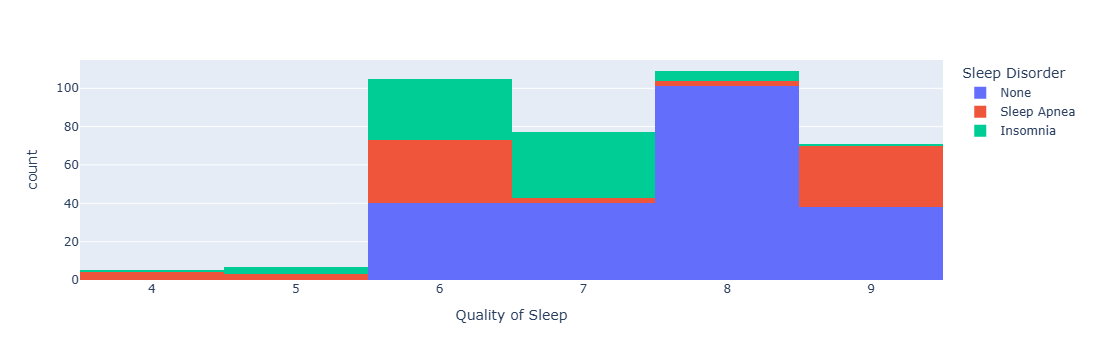

In [37]:
px.histogram(
    df,
    x="Quality of Sleep",
    color="Sleep Disorder"
)


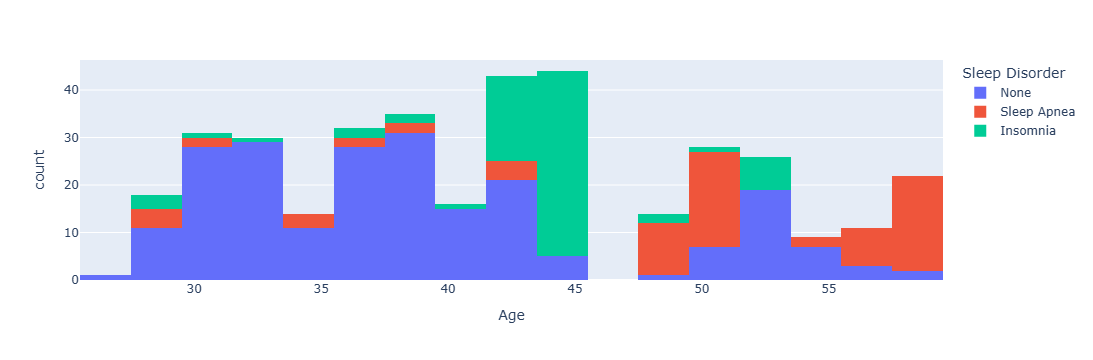

In [38]:
px.histogram(
    df,
    x="Age",
    color="Sleep Disorder"
)

# 男性は若い人が多い、女性は中年層が多い
# 女性の中年層が一番

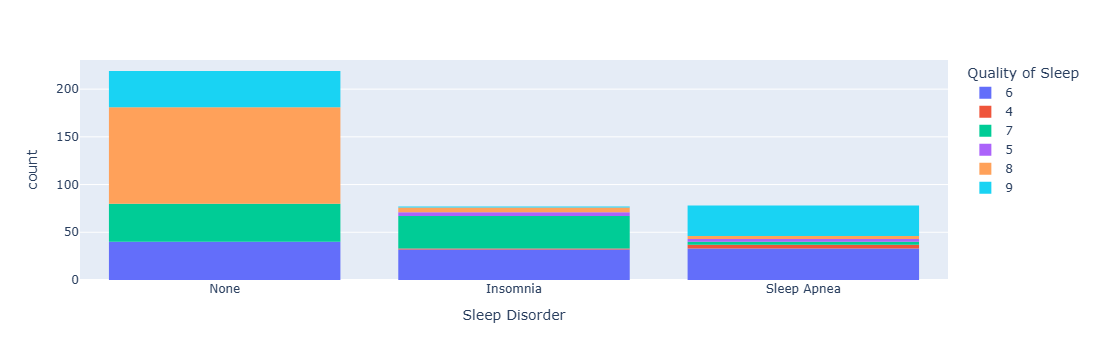

In [39]:
px.histogram(
    df,
    x="Sleep Disorder",
    color="Quality of Sleep"
)

# 睡眠障害がNoneである方が、睡眠の質は高くなる傾向から欠損値は睡眠障害無しであると捉えられる。

## 結果を見て感じたこと
- 年齢全体では、睡眠の質は年齢が高くなるほど高い傾向だった。
- 50代の人たちは睡眠時間を十分確保し、ストレスをあまり感じず、運動時間も使っているため、BMIにかかわらず健康意識が高い人が多いため、睡眠の質が高い。
- ストレスや運動時間や睡眠時間が睡眠の質に影響しやすいことが分かり、若い人はこれらの意識が低い傾向にあるため、睡眠の質が悪いと考えられる

**ただ、50代の睡眠の質の偏りが大きく、20代でも睡眠の質がそこまで高いとは言えない。**  
年齢が高い場合で睡眠の質が別の場合のパターンがこのデータにはなく、本来の年齢と睡眠の質との関係に反している傾向だった。  
ただ、先行研究では関連が指摘されているため説明変数として保持する。（重要度を見て判断する必要がある）

In [40]:
df.groupby("Age").size()

Age
27     1
28     5
29    13
30    13
31    18
32    17
33    13
34     2
35    12
36    12
37    20
38    20
39    15
40     4
41    12
42     9
43    34
44    30
45    14
48     3
49    11
50    20
51     8
52     9
53    17
54     7
55     2
56     2
57     9
58     6
59    16
dtype: int64

In [41]:

df[
    [
        "Age",
        "Gender",
        "Quality of Sleep",
        "Occupation"
    ]
]


,Age,Gender,Quality of Sleep,Occupation
0,27,Male,6,Software Engineer
1,28,Male,6,Doctor
2,28,Male,6,Doctor
3,28,Male,4,Sales Representative
4,28,Male,4,Sales Representative
...,...,...,...,...
369,59,Female,9,Nurse
370,59,Female,9,Nurse
371,59,Female,9,Nurse
372,59,Female,9,Nurse


## 職業について
職業ごとの社員数と睡眠の質の平均をまとめる。

In [42]:
# 職業による睡眠品質の平均

df_occupation_counts = df.groupby("Occupation")["Quality of Sleep"].agg(["mean", "count"]).sort_values("mean", ascending=False)
df_occupation_counts

# 結論：アプリに入れなくていい
# 理由：職種ごとににんずうが多いものもあればかなり少ないものもあるので、職種との関係性をはっきり決めれない。
# また、職種は簡単に変えられるものではないし、改善アドバイスに繋がらない。

,mean,count
Occupation,,
Engineer,8.412698,63
Lawyer,7.893617,47
Accountant,7.891892,37
Nurse,7.369863,73
Manager,7.000000,1
Teacher,6.975000,40
Doctor,6.647887,71
Software Engineer,6.500000,4
Salesperson,6.000000,32


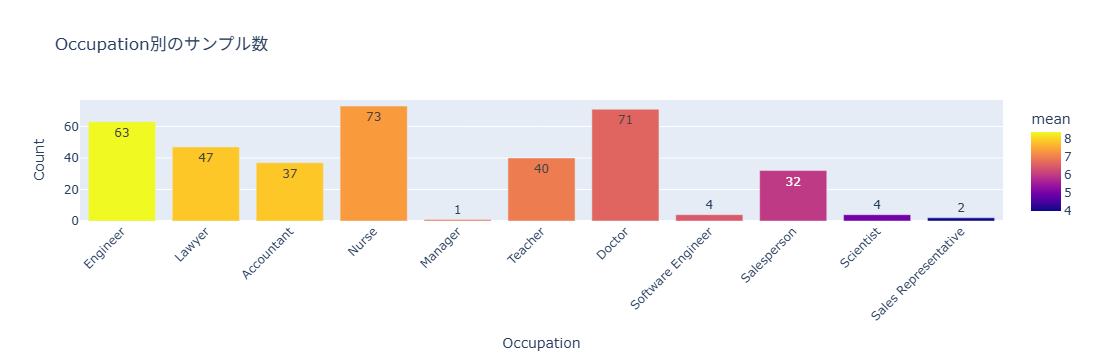

In [43]:
df_occupation_counts = df_occupation_counts.reset_index()

fig = px.bar(
    df_occupation_counts,
    x="Occupation",
    y="count",
    color="mean",  # 色で睡眠の質の平均を表現
    text="count",
    hover_data=["mean"],
    title="Occupation別のサンプル数"
)

fig.update_layout(
    xaxis_title="Occupation",
    yaxis_title="Count",
    xaxis_tickangle=-45
)

fig.show()

### 職業に関するまとめ
職業によっては数はもちろん、睡眠の質も偏りが見られた。  
ただ、睡眠の質を判定することを考えたときに、健康意識がある人でも職業で睡眠の質が決められてしまうかもしれない。  
また、職業ごとのサンプル数に大きな偏りがあり、一部の職業はサンプル数が極めて少ないため、この差を職業固有の影響と解釈することはできない。

## 睡眠障害の有無の設定

In [44]:
df["Sleep Disorder"] = df["Sleep Disorder"].apply(
    lambda x: "Yes" if x != "None" else "No"
)

In [45]:
df.groupby("Sleep Disorder")[
    "Quality of Sleep"
].mean()

Sleep Disorder
No     7.625571
Yes    6.870968
Name: Quality of Sleep, dtype: float64

In [46]:
# 加工したデータをcsvファイルに保存
df.to_csv("data/processed/Sleep_health_and_lifestyle_dataset_processed.csv")

## 結論

- 実際は年齢とともに睡眠の質が下がりがちであるのが調査によって明らかだが、今回の結果では逆に年齢の高い人ほど睡眠の質が上がるデータとなっていた。
    - 睡眠の質が若い人でも低いのは、BMIや運動時間といった健康面に起因する結果だった。
    - 特に50代半ば以降の睡眠の質が9しかなかったので、学習では年齢による影響を受けないように50代前半未満という風に年齢の範囲を設けた。
    - 
- 

### 特徴量に入れた方がいいもの
- Age
- Gender
- Sleep Duration
- Physical Activity Level
- Stress Level
- Heart Rate
- BMI(Height, weight)
- Sleep Disease

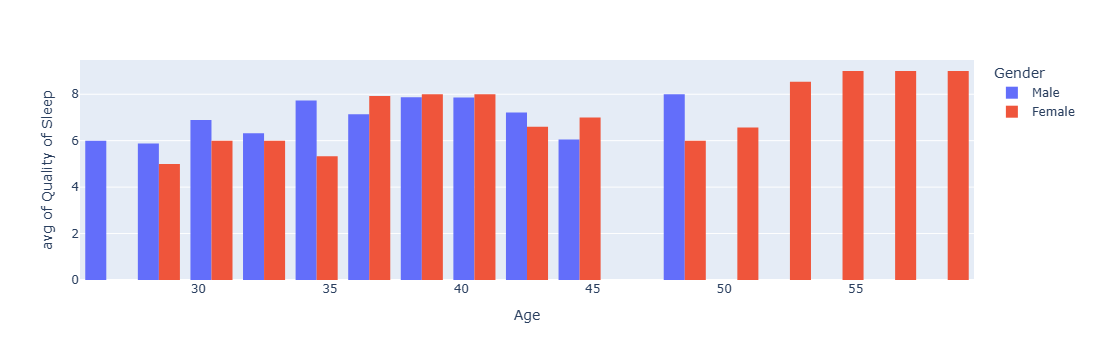

In [47]:
px.histogram(
    df,
    x="Age",
    y="Quality of Sleep",
    color="Gender",
    histfunc="avg",
    barmode="group"
)